# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown block to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [12]:
# Code block for important and creating data sets. Add more code blocks if needed.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display 

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_excel("car_prices.xlsx")

# Define feature matrix (X) and target vector (y)
y = df["Price (DKK)"].values
X = df.drop(columns=["Price (DKK)"]).values

# Extract feature names and add Intercept
feature_names = ["Intercept"] + list(df.drop(columns=["Price (DKK)"]).columns)

# Add a column of ones to X for the intercept term
X = np.c_[np.ones(X.shape[0]), X] 

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize X (excluding the first column which is the intercept)
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])  # Scale only feature columns
X_test[:, 1:] = scaler.transform(X_test[:, 1:])  # Use the same scaler for test set


## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.


### Task 1: Regression



Linear regression finds the best-fitting line (or hyperplane) by solving for the **coefficient vector** $\mathbf{B}$ that minimizes the squared error:

$$
\mathbf{B} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

where:
- $\mathbf{X}$ is the **design matrix**, including a column of ones for the intercept.
- $\mathbf{y}$ is the **response variable** (target values).
- $\mathbf{B}$ contains the **regression coefficients**.

**Explanation of Each Step**
1. **Construct the matrix $X$**:
   - Each **row** represents a data point.
   - Each **column** represents a feature.
   - The **first column is all ones** to account for the **intercept**.

2. **Solve for $\mathbf{B}$ using the normal equation**:
   - Compute $X^T X$ (feature correlation).
   - Compute $X^T y$ (cross-product with the target variable).
   - Compute the **inverse of $X^T X$** and multiply by $X^T y$ to get $\mathbf{B}$.

3. **Interpret the results**:
   - The **first value** in $\mathbf{B}$ is the **intercept**.
   - The remaining values are the **coefficients for each feature**.



In [16]:
# Use this for Task 1. Add more code blocks if needed.

# Compute the normal equation: B = (X^T X)^(-1) X^T y
B = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

# Pair feature names with their corresponding coefficients
coefficients = dict(zip(feature_names, B))

# Create a DataFrame to display the regression results
coefficients_df = pd.DataFrame(coefficients.items(), columns=["Feature", "Coefficient"])

# Display the regression coefficients using pandas
display(coefficients_df)

,Feature,Coefficient
0,Intercept,320080.058635
1,Model Year,25007.054556
2,Mileage (km),-15365.038887
3,Electric Range (km),10511.250034
4,Battery Capacity (kWh),802.032675
5,Energy Consumption (Wh/km),2703.743666
6,Annual Road Tax (DKK),-9338.347940
7,Horsepower (bhp),2677.899245
8,0-100 km/h (s),11466.392278
9,Top Speed (km/h),3808.271305


Task 2: Evaluating the Model

Once we have the regression coefficients $\mathbf{B}$, we can evaluate how well the model fits the data using two key metrics:

1. **Mean Squared Error (MSE)** – Measures the average squared difference between the predicted and actual values:
   $$
   MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
   $$
   - Lower MSE means better fit.

2. **$R^2$ (Coefficient of Determination)** – Measures how much of the variance in $y$ is explained by $X$:
   $$
   R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}
   $$
   - $R^2$ ranges from **0 to 1**, where **1** indicates a perfect fit and **0** means the model explains no variance.


**Explanation of Each Step**
1. **Compute Predictions**:  
   $$ \hat{y} = X B $$
   This gives the model’s predicted values.

2. **Compute MSE**:  
   - We square the residuals $ (y - \hat{y})^2 $ and take the mean.

3. **Compute $R^2$**:
   - **Total sum of squares** $ SS_{total} $ measures the total variance in $ y $.
   - **Residual sum of squares** $ SS_{residual} $ measures the variance left unexplained by the model.
   - $ R^2 $ tells us what fraction of variance is explained.

**Interpreting the Results**
- **MSE**: Lower values indicate a better fit.
- **$R^2$ Score**:
  - **$R^2 = 1$** → Perfect fit (all points on the regression line).
  - **$R^2 = 0$** → Model is no better than predicting the mean of $ y $.
  - **$R^2 < 0$** → Model performs worse than a simple average.

Implement the above steps using linear algebra so that you both create a regression model and calculate the MSE and $R^2$. Note, here you need to use `X_train`, `X_test`, `y_train` and `y_test` appropriately!


In [17]:
# Use this for Task 2. Add more code blocks if needed.

# Compute predictions on the test set
y_pred = X_test @ B

# Compute Mean Squared Error (MSE)
mse = np.mean((y_test - y_pred) ** 2)

# Compute R² (Coefficient of Determination)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)  # Total sum of squares (SStotal)
ss_residual = np.sum((y_test - y_pred) ** 2)  # Residual sum of squares (SSresidual)
r2_score = 1 - (ss_residual / ss_total)  # R² formula

# Display results
evaluation_metrics = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "R² Score"],
    "Value": [mse, r2_score]
})

display(evaluation_metrics)

,Metric,Value
0,Mean Squared Error (MSE),2.774487e+09
1,R² Score,8.644264e-01


# Part 2: Using Library Functions

### Task 4: Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


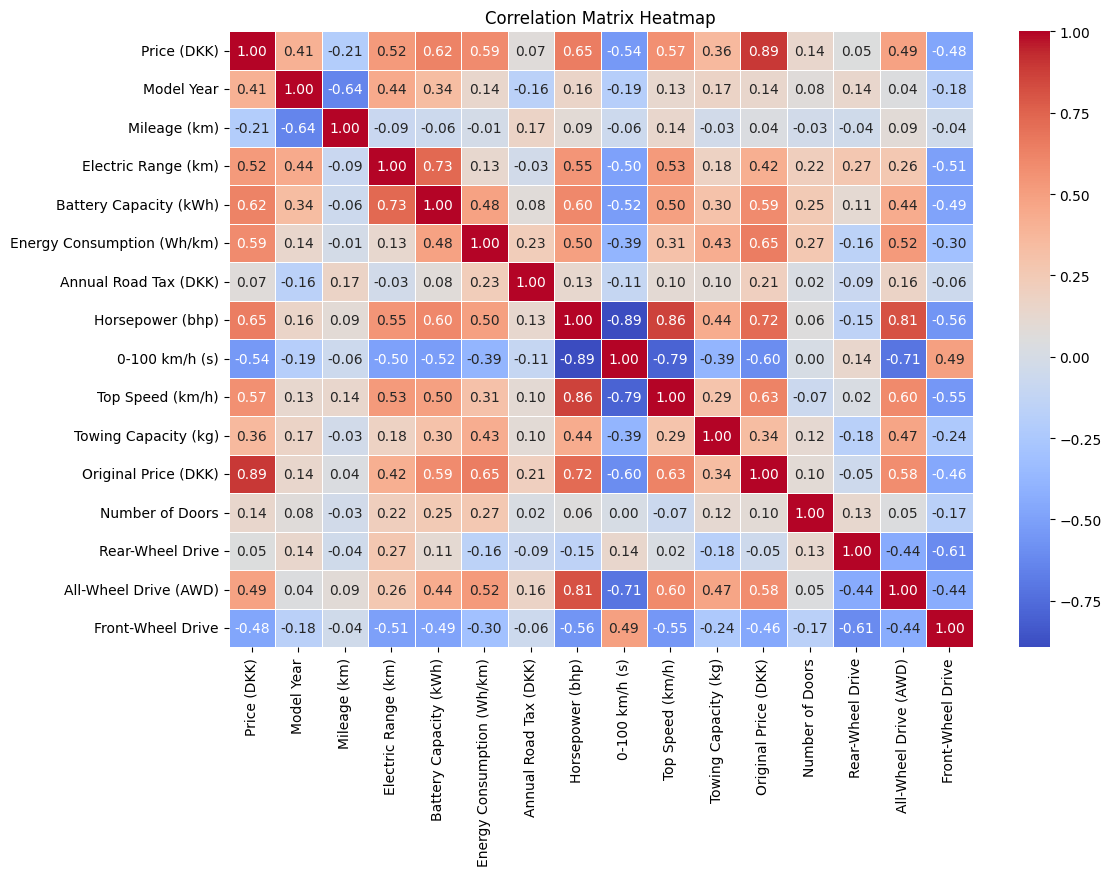

,Metric,Value
0,Mean Squared Error (MSE),2.272994e+09
1,Root Mean Squared Error (RMSE),4.767593e+04
2,R² Score,8.958552e-01


In [24]:
# Use this for Task 4. Add more code blocks if needed.
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Task 4: Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Create a heatmap with correlation values displayed
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

# Add intercept manually for OLS
X_ols = sm.add_constant(X)  

# Fit the OLS model
ols_model = sm.OLS(y, X_ols).fit()

# Display OLS summary
ols_summary = ols_model.summary()
ols_summary

# Compute predictions using the OLS model
y_pred_ols = ols_model.predict(X_ols)

# Compute MSE (Mean Squared Error)
mse_ols = np.mean((y - y_pred_ols) ** 2)

# Compute RMSE (Root Mean Squared Error)
rmse_ols = np.sqrt(mse_ols)

# Compute R² (Coefficient of Determination) from the OLS model
r2_ols = ols_model.rsquared

# Display performance metrics
performance_metrics_ols = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [mse_ols, rmse_ols, r2_ols]
})

# Display the results using IPython display
display(performance_metrics_ols)


With a lower MSE(therefore also lower RMSE) in this model compared to the Linear regression model in task 2, we can conclude that OLS is more precise with this dataset. A RMSE of 47.676DKK is a deviance of 10-15% when looking at cars priced 300.000-500.000DKK, which is okay for a general prediction model. If a precise prediction is the goal, the deviance is too high.
R2 Score of 0,896 is higher than the task 2 model, which means that a higher percentage of variance is explained in the OLS model, and that the model effectively captures the relationship between features and price.

### Task 5: Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For the final task you must do the following
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [26]:
# Use this for Task 5. Add more code blocks if needed.
# Import necessary libraries for Ridge, Lasso, and Elastic Net Regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

# Step 1: Standardize Data
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train[:, 1:])  # Exclude intercept column
X_test_scaled = scaler_X.transform(X_test[:, 1:])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Step 2: Train Ridge, Lasso, and Elastic Net Models with multiple alpha values
alphas = [0.01, 0.1, 1, 10, 100]  # Different levels of regularization

ridge_results, lasso_results, elastic_net_results = [], [], []

for alpha in alphas:
    # Ridge Regression
    ridge = Ridge(alpha=alpha, max_iter=100000)
    ridge.fit(X_train_scaled, y_train_scaled)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_mse = mean_squared_error(y_test_scaled, ridge_pred)
    ridge_r2 = ridge.score(X_test_scaled, y_test_scaled)
    ridge_results.append([alpha, ridge_mse, np.sqrt(ridge_mse), ridge_r2])

    # Lasso Regression
    lasso = Lasso(alpha=alpha, max_iter=100000)
    lasso.fit(X_train_scaled, y_train_scaled)
    lasso_pred = lasso.predict(X_test_scaled)
    lasso_mse = mean_squared_error(y_test_scaled, lasso_pred)
    lasso_r2 = lasso.score(X_test_scaled, y_test_scaled)
    lasso_results.append([alpha, lasso_mse, np.sqrt(lasso_mse), lasso_r2])

    # Elastic Net Regression
    elastic_net = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=100000)
    elastic_net.fit(X_train_scaled, y_train_scaled)
    elastic_net_pred = elastic_net.predict(X_test_scaled)
    elastic_net_mse = mean_squared_error(y_test_scaled, elastic_net_pred)
    elastic_net_r2 = elastic_net.score(X_test_scaled, y_test_scaled)
    elastic_net_results.append([alpha, elastic_net_mse, np.sqrt(elastic_net_mse), elastic_net_r2])

# Convert results to DataFrame for easy interpretation
ridge_df = pd.DataFrame(ridge_results, columns=["Alpha", "MSE", "RMSE", "R²"])
lasso_df = pd.DataFrame(lasso_results, columns=["Alpha", "MSE", "RMSE", "R²"])
elastic_net_df = pd.DataFrame(elastic_net_results, columns=["Alpha", "MSE", "RMSE", "R²"])

# Display results
display(ridge_df)
display(lasso_df)
display(elastic_net_df)


,Alpha,MSE,RMSE,R²
0,0.01,0.125188,0.353819,0.864426
1,0.10,0.125189,0.353820,0.864425
2,1.00,0.125197,0.353833,0.864416
3,10.00,0.125291,0.353965,0.864315
4,100.00,0.126603,0.355813,0.862894


,Alpha,MSE,RMSE,R²
0,0.01,0.122946,0.350636,0.866854
1,0.10,0.148866,0.385831,0.838784
2,1.00,0.924087,0.961295,-0.000753
3,10.00,0.924087,0.961295,-0.000753
4,100.00,0.924087,0.961295,-0.000753


,Alpha,MSE,RMSE,R²
0,0.01,0.123783,0.351828,0.865947
1,0.10,0.135476,0.368070,0.853285
2,1.00,0.566144,0.752425,0.386887
3,10.00,0.924087,0.961295,-0.000753
4,100.00,0.924087,0.961295,-0.000753


In all 3 models, the lowest alpha gives the best results, where Lasso slightly outperforms the others.

In [27]:
# Rebuild OLS Model using Scaled Data
X_train_scaled_ols = sm.add_constant(X_train_scaled)  # Add intercept for OLS
X_test_scaled_ols = sm.add_constant(X_test_scaled)

ols_model_scaled = sm.OLS(y_train_scaled, X_train_scaled_ols).fit()

# Display OLS summary
ols_summary_scaled = ols_model_scaled.summary()
ols_summary_scaled

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     3284.
Date:                Mon, 24 Feb 2025   Prob (F-statistic):               0.00
Time:                        17:05:43   Log-Likelihood:                -1269.1
No. Observations:                4980   AIC:                             2568.
Df Residuals:                    4965   BIC:                             2666.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        4.51e-17      0.004   1.02e-14      1.000      -0.009       0.009
x1             0.1680      0.007     24.192      0.000       0.154       0.182
x2            -0.1032      0.006    -16.684      0.000      -0.115      -0.091
x3             0.0706      0.008      8.326      0.000       0.054       0.087
x4             0.0054      0.008      0.712      0.477      -0.009       0.020
x5             0.0182      0.007      2.477      0.013       0.004       0.033
x6            -0.0627      0.005    -13.216      0.000      -0.072      -0.053
x7             0.0180      0.017      1.049      0.294      -0.016       0.052
x8             0.0770      0.010      7.565      0.000       0.057       0.097
x9             0.0256      0.010      2.530      0.011       0.006       0.045
x10            0.0475      0.005      8.989      0.000       0.037       0.058
x11            0.8500      0.008    111.748      0.000       0.835       0.865
x12            0.0111      0.005      2.204      0.028       0.001       0.021
x13            0.0244      0.004      6.671      0.000       0.017       0.032
x14           -0.0145      0.006     -2.275      0.023      -0.027      -0.002
x15           -0.0117      0.004     -2.671      0.008      -0.020      -0.003
==============================================================================
Omnibus:                     1193.714   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            71854.558
Skew:                          -0.070   Prob(JB):                         0.00
Kurtosis:                      21.608   Cond. No.                     3.81e+15
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.99e-27. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

The best R2 result yet, which means that 90,3% of variance is explained by the model, which is a strong fit.
The 3 most important coefficients are Original Price, Model year and mileage, where original price is leading by far in importance. This tells us that the more expensive a car was from new, the younger it is, and the shorter its mileage, has the biggest saying on the current price.
The OLS also says the there is a high chance of multicollinearity which means that some features are highly correlated and should be reduced.

In [30]:
# Retrieve the best alpha values for Ridge and Lasso from previous analysis
best_ridge_alpha = ridge_df.loc[ridge_df["MSE"].idxmin(), "Alpha"]
best_lasso_alpha = lasso_df.loc[lasso_df["MSE"].idxmin(), "Alpha"]

# Train Ridge and Lasso with the best alpha values
best_ridge_model = Ridge(alpha=best_ridge_alpha, max_iter=100000)
best_ridge_model.fit(X_train_scaled, y_train_scaled)
ridge_coefficients = best_ridge_model.coef_

best_lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=100000)
best_lasso_model.fit(X_train_scaled, y_train_scaled)
lasso_coefficients = best_lasso_model.coef_

# Extract OLS coefficients
ols_coefficients = ols_model_scaled.params[1:]  # Exclude intercept

# Create DataFrames for easy comparison
ridge_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": ridge_coefficients})
lasso_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": lasso_coefficients})
ols_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": ols_coefficients})

# Select top 5 most important features (based on absolute values of coefficients)
ridge_top5 = ridge_df.reindex(ridge_df["Coefficient"].abs().nlargest(5).index)
lasso_top5 = lasso_df.reindex(lasso_df["Coefficient"].abs().nlargest(5).index)
ols_top5 = ols_df.reindex(ols_df["Coefficient"].abs().nlargest(5).index)

# Display the results
display(ridge_top5)
display(lasso_top5)
display(ols_top5)



,Feature,Coefficient
10,Original Price (DKK),0.850034
0,Model Year,0.167977
1,Mileage (km),-0.103211
7,0-100 km/h (s),0.077022
2,Electric Range (km),0.070607


,Feature,Coefficient
10,Original Price (DKK),0.841904
0,Model Year,0.169126
1,Mileage (km),-0.094831
2,Electric Range (km),0.063393
5,Annual Road Tax (DKK),-0.051178


,Feature,Coefficient
10,Original Price (DKK),0.850039
0,Model Year,0.167978
1,Mileage (km),-0.103210
7,0-100 km/h (s),0.077022
2,Electric Range (km),0.070606


Ridge and OLS agree 100% on the 5 most important features, where lasso disagrees on important features #4 and #5. The coefficients on those two features are however very low, so it makes little to no difference for the overall prediction capabilities of the model. It's also important to point out that Lasso provides a simpler model by removing redundant features, which could be why it has other features as #4 and #5 on the most important list.
Overall the models mostly agree on important features, and I think it's safe to say that the 3 most important features are the most defining features, where #1 is significantly more important than the others, as seen by the big jump in coefficient size.